# CIND820 XJH - Big Data Analytics Project: Milestone 3
**Author:** Fatima Aghapourasl

## 1. Introduction and Loading Data
In this notebook, I will perform Data Aggregation, Feature Engineering, and Exploratory Data Analysis (EDA) to answer my three Research Questions. First, I will load the raw datasets and the necessary Python libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
print("All datasets loaded successfully!")

All datasets loaded successfully!


## 2. Data Aggregation (Replicating SQL Logic)
To avoid double-counting revenue (since one order can have multiple payment installments or items), I need to group the payments and reviews by `order_id` before merging them into my main dataset.

In [3]:
# Group payments by order_id so each order has only one total revenue row
payments_grouped = payments.groupby('order_id')['payment_value'].sum().reset_index()
payments_grouped.rename(columns={'payment_value': 'total_payment'}, inplace=True)

# Group reviews by order_id (taking the average score if a customer left multiple reviews)
reviews_grouped = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Now, I will merge everything to create the 'order_master' table
order_master = pd.merge(orders, customers, on='customer_id', how='left')
order_master = pd.merge(order_master, payments_grouped, on='order_id', how='left')
order_master = pd.merge(order_master, reviews_grouped, on='order_id', how='left')

print("Master table created. Total rows:", len(order_master))

Master table created. Total rows: 99441


In [4]:
len(order_master.columns)


14

In [5]:
order_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'total_payment', 'review_score'],
      dtype='object')

In [6]:
order_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,5.0


In [7]:
# Dropping unnecessary columns to clean up the master dataset
columns_to_drop= [
    'customer_zip_code_prefix', 
    'customer_city', 
    'order_approved_at', 
    'order_delivered_carrier_date'
]
order_master= order_master.drop(columns=columns_to_drop)
print('column lengths:', len(order_master.columns))

column lengths: 10


In [8]:
order_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'total_payment',
       'review_score'],
      dtype='object')

## 3. Feature Engineering (Derived Variables)
As suggested in the feedback, I need to create explicit derived variables for my analysis:
1. `delivery_delay_days`: I will calculate this by subtracting the estimated delivery date from the actual delivery date. 
2. `order_month`: I will extract just the Year and Month from the purchase timestamp to analyze seasonality.

In [13]:
# First, convert the string dates into actual Datetime objects
order_master['actual_delivery'] = pd.to_datetime(order_master['order_delivered_customer_date'])
order_master['estimated_delivery'] = pd.to_datetime(order_master['order_estimated_delivery_date'])
order_master['purchase_date'] = pd.to_datetime(order_master['order_purchase_timestamp'])

# Calculate the delay in days (Positive number = delayed, Negative number = arrived early)
order_master['delivery_delay_days'] = (order_master['actual_delivery'] - order_master['estimated_delivery']).dt.days

# Extract the year and month (e.g., '2017-11' for November 2017)
order_master['order_month'] = order_master['purchase_date'].dt.strftime('%Y-%m')

# Check the new columns
order_master[['order_id', 'delivery_delay_days', 'order_month']].head(10)

,order_id,delivery_delay_days,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,2018-02
5,a4591c265e18cb1dcee52889e2d8acc3,-6.0,2017-07
6,136cce7faa42fdb2cefd53fdc79a6098,NaN,2017-04
7,6514b8ad8028c9f2cc2374ded245783f,-12.0,2017-05
8,76c6e866289321a7c93b82b54852dc33,-32.0,2017-01
9,e69bfb5eb88e0ed6a785585b27e16dbf,-7.0,2017-07


### 💡 Data Architecture & SQL Prototyping
*Note: Before writing the Pandas aggregation code below, I initially designed the data models and resolved the One-to-Many relationships (to prevent double-counting) using SQL. The original SQL queries can be found in the `data_aggregation_queries.sql` file in my GitHub repository. I then translated that logic into Python for full reproducibility here.*

## 4. Answering Research Questions

### RQ1: Monthly Revenue Trends (2017 - 2018)
I want to see which months generate the most revenue to identify peak seasonality.

Sample Size for RQ1 (All orders): N = 99441


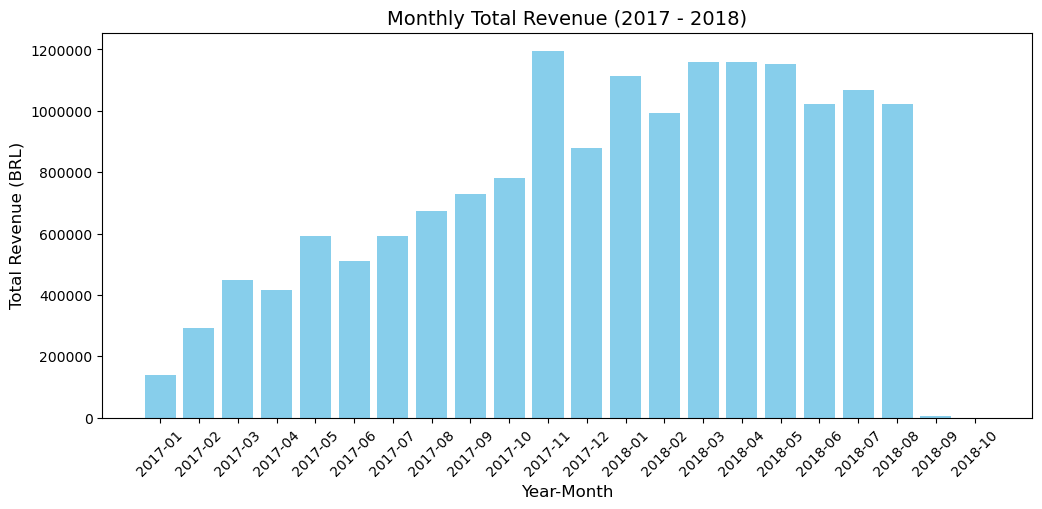

In [14]:
# Report the sample size for RQ1
print(f"Sample Size for RQ1 (All orders): N = {len(order_master)}")

# Keep only 2017 and 2018 data for a clean chart
sales_17_18 = order_master[order_master['order_month'].str.startswith(('2017', '2018'), na=False)]

# Calculate total revenue per month
monthly_revenue = sales_17_18.groupby('order_month')['total_payment'].sum().reset_index()

# Plot the bar chart
plt.figure(figsize=(12, 5))
plt.bar(monthly_revenue['order_month'], monthly_revenue['total_payment'], color='skyblue')
plt.title('Monthly Total Revenue (2017 - 2018)', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation (e.g., 1e6)
plt.show()

### RQ2: Delivery Delay and Customer Satisfaction
**Methodology Justification:** I am using the **Spearman Rank-Order Correlation** test instead of Pearson. This is because my dependent variable (`review_score`) is an ordinal category (1 to 5 stars), and delivery delays do not follow a normal distribution. Spearman is the mathematically robust choice here.

In [15]:
# To test this, I must drop rows where the order hasn't been delivered or has no review
clean_data_rq2 = order_master.dropna(subset=['delivery_delay_days', 'review_score'])

# Report the exact sample size after cleaning
print(f"Sample Size for RQ2 (Completed orders only): N = {len(clean_data_rq2)}")

# Run the Spearman correlation test
correlation, p_value = spearmanr(clean_data_rq2['delivery_delay_days'], clean_data_rq2['review_score'])

print(f"Spearman Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: The p-value is less than 0.05. There is a statistically significant negative association between delays and customer satisfaction.")

Sample Size for RQ2 (Completed orders only): N = 95830
Spearman Correlation: -0.1761
P-value: 0.0000e+00
Conclusion: The p-value is less than 0.05. There is a statistically significant negative association between delays and customer satisfaction.


### RQ3: State-Level Comparisons
Finally, I will look at the geographical data to see which 5 Brazilian states generate the highest total revenue for the company.

Sample Size for RQ3: N = 99441


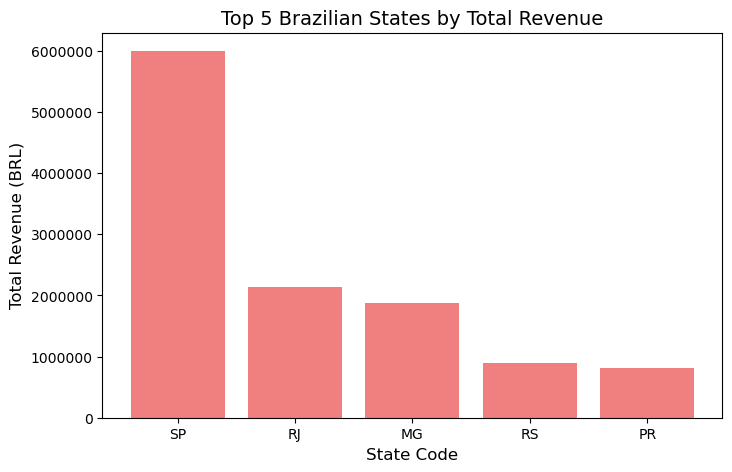

In [16]:
# Report the sample size for RQ3
print(f"Sample Size for RQ3: N = {len(order_master)}")

# Group data by Customer State and sum the revenue
state_revenue = order_master.groupby('customer_state')['total_payment'].sum().reset_index()

# Sort the values to find the top 5 states
top_5_states = state_revenue.sort_values(by='total_payment', ascending=False).head(5)

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(top_5_states['customer_state'], top_5_states['total_payment'], color='lightcoral')
plt.title('Top 5 Brazilian States by Total Revenue', fontsize=14)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()